# EDA

# Exploratory Data Analysis



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
merged_df = pd.read_csv('/content/merged_data.csv')

##### Stock Data Analysis

1. `Price Statistics`:
To get a quick overview of the stock prices (Open, High, Low, Close), we calculate key summary statistics (mean, median, min, max, std). This helps understand the typical range and volatility of the prices.

2. `Price Change (Close - Open) Distribution`:
By plotting the distribution of daily price changes (Close - Open), we can check if stock movements are normally distributed, skewed, or have heavy tails — important for modeling returns and risk.

  The distribution of daily price changes for Apple stock is roughly centered around zero, indicating that small gains and losses are most common. However, there is a slight positive skew, suggesting that Apple more frequently closes slightly higher than it opens.

3. `Volume Distribution (Log-Scaled)`:
Volume data is often heavily right-skewed, meaning a few days have extremely high trading. Applying a log transformation helps normalize the distribution for better visualization and later modeling.

  The graph shows that there is a a peak around log(1 + volume) 18. This suggests that most trading volumes cluster around that value. The log transformation was effective in reducing skewness and making the distribution more symmetrical, which is important for modeling tasks like regression.     


In [ ]:
# Price Statistics
price_stats = merged_df[['Open', 'High', 'Low', 'Close']].agg(['mean', 'median', 'min', 'max', 'std'])
print("Price Statistics:\n", price_stats)

Price Statistics:
               Open        High         Low       Close
mean    160.981877  162.810599  159.321786  161.165832
median  158.905153  161.257473  156.868168  159.194550
min      21.836885   22.009760   21.791392   21.845984
max     235.687872  236.968462  233.935137  235.960678
std      26.496366   26.591405   26.371902   26.505709


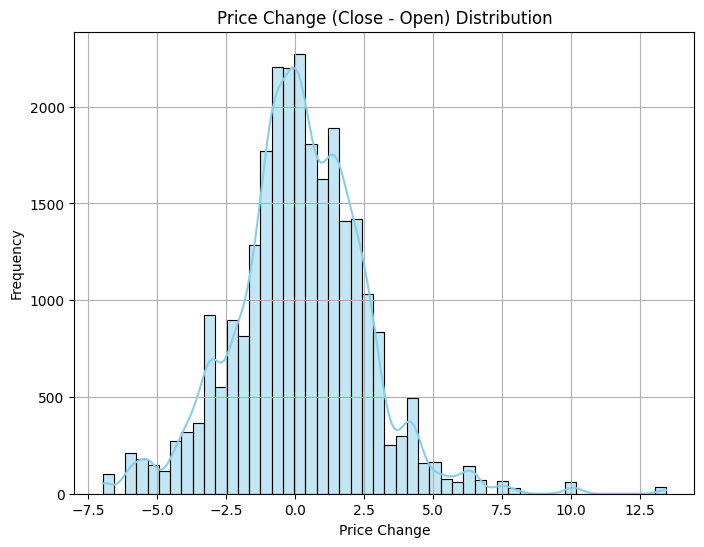

In [ ]:
# Price Change
# Create a new column for price change
merged_df['Price_Change'] = merged_df['Close'] - merged_df['Open']

# Plot the distribution
plt.figure(figsize=(8, 6))
sns.histplot(merged_df['Price_Change'], bins=50, kde=True, color='skyblue')
plt.title('Price Change (Close - Open) Distribution')
plt.xlabel('Price Change')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

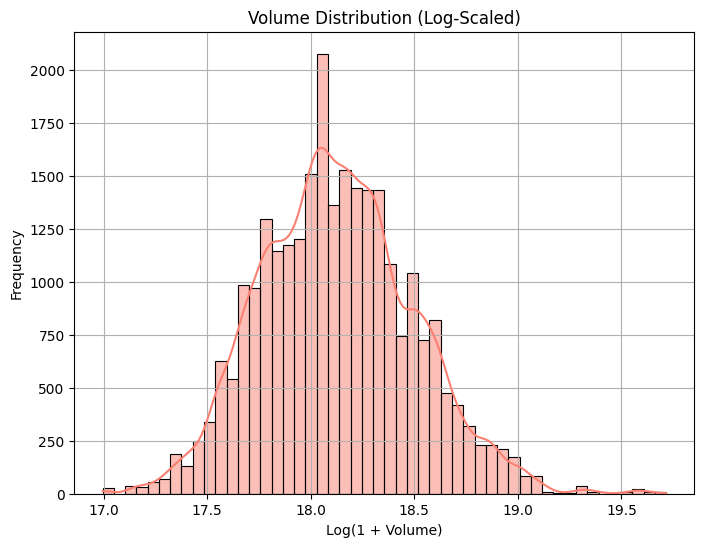

In [ ]:
# Volume distribution (log scale)
# Check skewness
volume_skewness = merged_df['Volume'].skew()

# Plot volume distribution
plt.figure(figsize=(8, 6))
if abs(volume_skewness) > 1:
    sns.histplot(np.log1p(merged_df['Volume']), bins=50, kde=True, color='salmon')
    plt.title('Volume Distribution (Log-Scaled)')
    plt.xlabel('Log(1 + Volume)')
else:
    sns.histplot(merged_df['Volume'], bins=50, kde=True, color='salmon')
    plt.title('Volume Distribution')
    plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

##### Time Series Analysis
1. `Close Price Over Time`: Plotting the Close price over time helps detect overall market trends, cycles, or unusual price jumps, providing intuition on the stock's behavior historically.

  The graph shows that there is a clear upward trend over time, meaning Apple's stock generally gained value historically. The short-term fluctuations (ups and downs) are visible, often around key events like product launches or earnings announcements.

2. `Volume Over Time`: Volume over time shows the intensity of trading activity, which often correlates with important events, news releases, or price volatility spikes

    Here, spikes in volume could potential indicate events. Higher trading volume often signals high investor interest, leading to greater price volatility (larger up or down moves).Stable or low volume periods suggest less market excitement and smaller price changes.

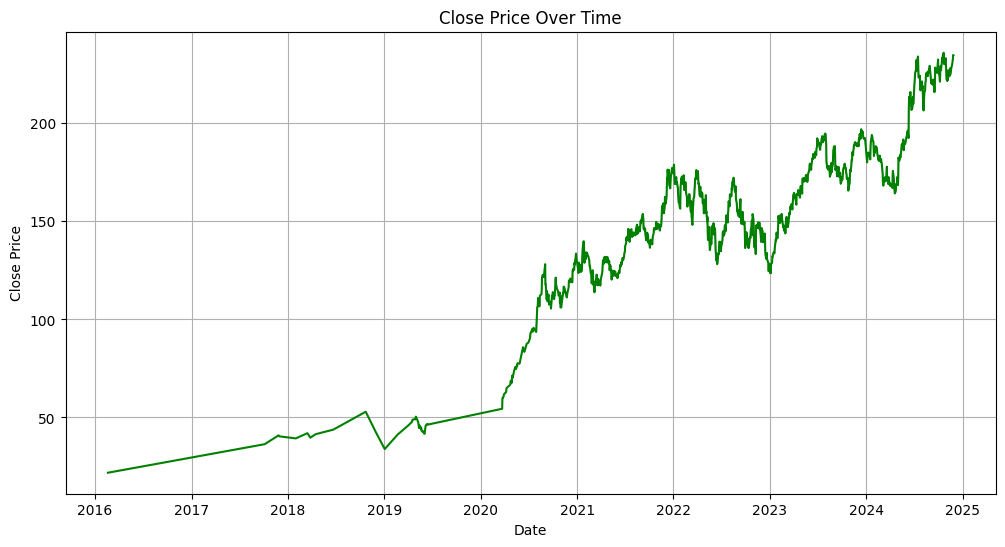

In [ ]:
# Close Price Over Time

merged_df['date'] = pd.to_datetime(merged_df['date'])

# Sort by date
df_sorted = merged_df.sort_values('date')

# Plot Close price over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='Close', data=df_sorted, color='green')
plt.title('Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()


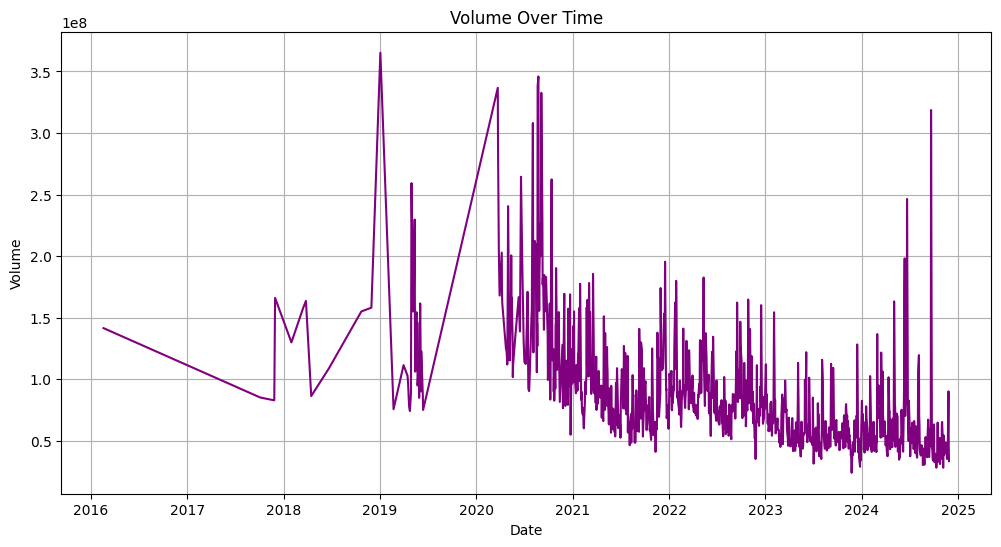

In [ ]:
# Plot Volume over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='Volume', data=df_sorted, color='purple')
plt.title('Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

##### Text Analysis

To better understand the underlying themes and focus areas within the financial news articles, we performed text analysis on both the titles and the content. By visualizing the most frequent words, we can learn more about key entities, topics, and sentiment drivers that influence stock price movements.

From the analysis, it can be seen that terms like "apple" "stock" "buy" "nasdaq" "hedge fund" and "dow jones" appeared very frequently. This suggests a focus on major tech companies, market indices (NASDAQ, Dow Jones), and investment actions(for instance, buy recommendations, hedge fund activity). These shows that investor sentiment and news coverage are closely tied to stocks and market trends.

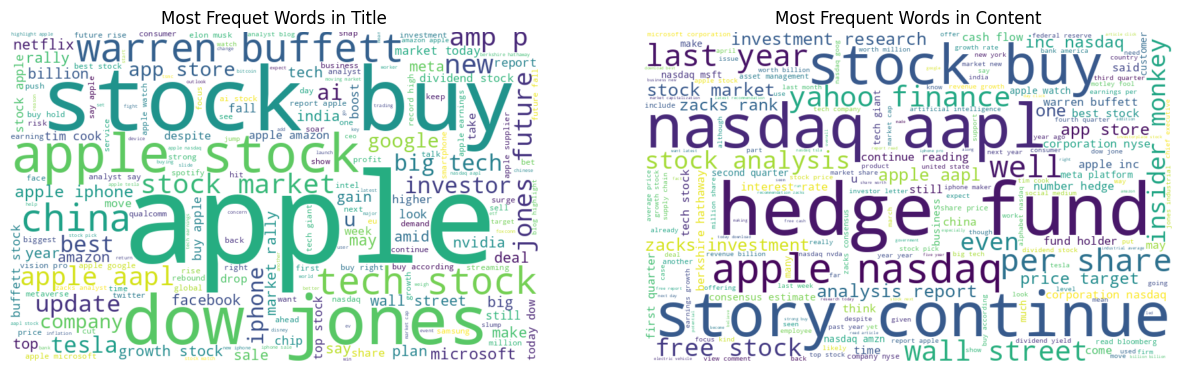

In [ ]:
# subplots to show graphs next to each other
fig, axes = plt.subplots(1,2, figsize = (15,5))

# Word cloud for Title
from wordcloud import WordCloud

text_title = ' '.join([word for tokens in merged_df['tokenized_title'] for word in tokens if word not in stop_words])
wordcloud = WordCloud(width = 800, height = 500, background_color = 'white').generate(text_title)
axes[0].imshow(wordcloud, interpolation='bilinear')
axes[0].set_axis_off()
axes[0].set_title('Most Frequet Words in Title')

# Word clousd for Content
from wordcloud import WordCloud

text_content = ' '.join([word for tokens in merged_df['tokenized_content'] for word in tokens if word not in stop_words])
wordcloud = WordCloud(width = 800, height = 500, background_color = 'white').generate(text_content)
axes[1].imshow(wordcloud, interpolation='bilinear')
axes[1].set_axis_off()
axes[1].set_title('Most Frequent Words in Content')

plt.show()

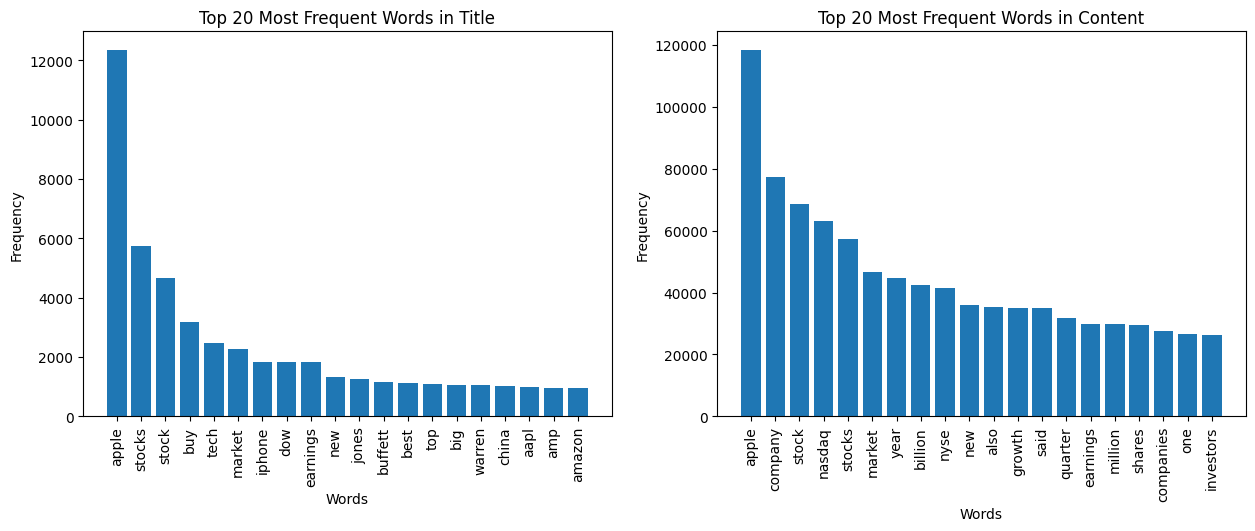

In [ ]:
# Calculating word frequencies
word_counts_title = Counter([word for tokens in news_df['tokenized_title'] for word in tokens]).most_common(20)
words_title = [word for word, count in word_counts_title]
freq_title = [count for word, count in word_counts_title]

word_counts_content = Counter([word for tokens in news_df['tokenized_content'] for word in tokens]).most_common(20)
words_content = [word for word, count in word_counts_content] # Fixed: Using word_counts_content instead of word_counts_title
freq_content = [count for word, count in word_counts_content] # Fixed: Using word_counts_content instead of word_counts_title


fig, axes = plt.subplots(1,2, figsize = (15,5)) # Fixed: Changed size to axes

# Most frequent words in Title
axes[0].bar(words_title,freq_title)
axes[0].set_title('Top 20 Most Frequent Words in Title')
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks(range(len(words_title))) # Fixed: Providing tick positions
axes[0].set_xticklabels(words_title, rotation=90) # Fixed: Setting tick labels with rotation


# Most frequent words in Content
axes[1].bar(words_content,freq_content) # Fixed: Removed ax = [1]
axes[1].set_title('Top 20 Most Frequent Words in Content')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')
axes[1].set_xticks(range(len(words_content))) # Fixed: Providing tick positions
axes[1].set_xticklabels(words_content, rotation=90) # Fixed: Setting tick labels with rotation

plt.show()

##### Symbol Exploration

To better understand the market relationships highlighted in the news, we analyzed stocks frequently mentioned alongside AAPL; the visualization reveals key companies and tickers that often share coverage with Apple, suggesting thematic or sector-based connections influencing investor attention.

Many top co-occurring symbols like AAPL34.SA, AAPL.MX, APC.F, and APC.XETRA are international listings or variants of Apple on different stock exchanges (e.g., Brazil, Mexico, Germany) stating that news articles mentioning AAPL often reference its global presence across markets. Other symbols like AMZN.US (Amazon) and GOOGL.US (Google) show up frequently. News coverage may bundle these companies together in discussions like technology trends, market leadership, earnings seasons, etc.

In [ ]:
# Symbol Exploration
merged_df['symbols'].value_counts()

,count
symbols,
"AAPL.MX, AAPL.US, AAPL34.SA, APC.F, APC.XETRA",4246
"AAPL.US, AAPL34.SA",1011
AAPL.US,831
"0R2V.IL, AAPL.BA, AAPL.MX, AAPL.NEO, AAPL.SN, AAPL.US, AAPL34.SA, APC.BE, APC.DU, APC.F, APC.HA, APC.HM, APC.MU, APC.STU, APC.XETRA, APC8.F",715
"AAPL.MX, AAPL.US, AAPL34.SA, ABEA.F, ABEA.XETRA, ABEC.F, ABEC.XETRA, APC.F, APC.XETRA, GOGL34.SA, GOGL35.SA, GOOG.MI, GOOG.MX, GOOG.US, GOOGL.US",248
...,...
"AAPL.MX, AAPL.US, AAPL34.SA, APC.F, APC.XETRA, DIS.MX, DIS.US, DISB34.SA, GOS.F, GOS.XETRA, GS-PA.US, GS-PD.US, GS-PJ.US, GS-PK.US, GS.MX, GS.US, GSBD.US",1
"AAPL.US, AMZN.US, BBBY.US, COIN.US, DJI.INDX, META.US, MSF.F, MSF.XETRA, MSFT.MX, MSFT.US, MSFT34.SA, NFLX.US, WBD.US",1
"9988.HK, AAPL.MX, AAPL.US, AAPL34.SA, AHLA.F, AHLA.XETRA, APC.F, APC.XETRA, BABA.US, BABA34.SA, BABAF.US, GSPC.INDX",1


In [ ]:
# Most common co-occurring symbols with AAPL

import re
from collections import Counter

co_occurrences = Counter()

# Filter rows where 'symbols' contains 'AAPL'
aapl_data = merged_df[merged_df['symbols'].str.contains('AAPL', na=False)]

for symbol_list in aapl_data['symbols']:
    # Extract symbols
    symbols = re.findall(r'[A-Z\d.]+', symbol_list)

    # Remove AAPL versions
    symbols = [s for s in symbols if s not in ('AAPL', 'AAPL.US')]

    # Update counter
    co_occurrences.update(symbols)

# Top 10 most common
most_common_symbols = co_occurrences.most_common(10)
print(most_common_symbols)


[('AAPL34.SA', 19068), ('AAPL.MX', 15898), ('APC.F', 15405), ('APC.XETRA', 15156), ('AMZN.US', 4772), ('GOOGL.US', 3335), ('ABEA.F', 3137), ('ABEA.XETRA', 3118), ('ABEC.F', 3107), ('ABEC.XETRA', 3073)]


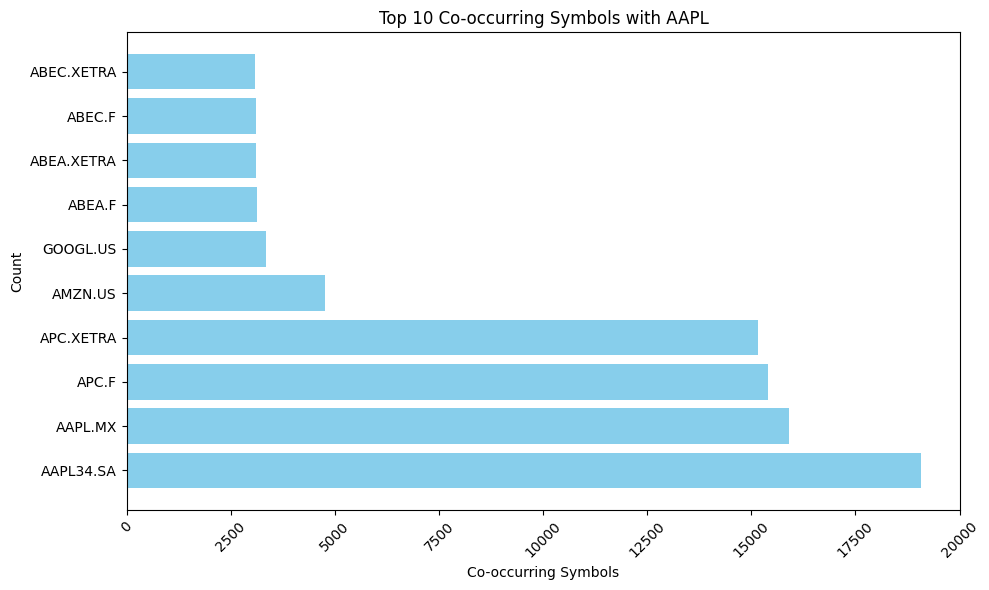

In [ ]:
# Unpack most_common_symbols into two lists
symbols = [symbol for symbol, _ in most_common_symbols]
counts = [count for _, count in most_common_symbols]

# Plot
plt.figure(figsize=(10,6))
plt.barh(symbols, counts, color='skyblue')
plt.xlabel('Co-occurring Symbols')
plt.ylabel('Count')
plt.title('Top 10 Co-occurring Symbols with AAPL')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()